## Exercise 2
* Part 1

In [27]:
import pandas as pd

df = pd.read_csv('for_nitpicker.dat', sep='\t', header=None)

# Add column headers
df.columns = ["Date", "Time", "Depth_m", "Temperature_°C", "Salinity_PSU"]

# Save back as tab-separated file
df.to_csv('CTD_11292008_0652', index=False)

print(df.head())

         Date   Time  Depth_m  Temperature_°C  Salinity_PSU
0  11/29/2008  06:52        5           28.97         35.21
1  11/29/2008  06:52        6           28.98         35.21
2  11/29/2008  06:52        7           28.99         35.21
3  11/29/2008  06:52        8           28.96         35.21
4  11/29/2008  06:52        9           28.99         35.21


* Part 2

In [28]:
import matplotlib.pyplot as plt
import numpy as np

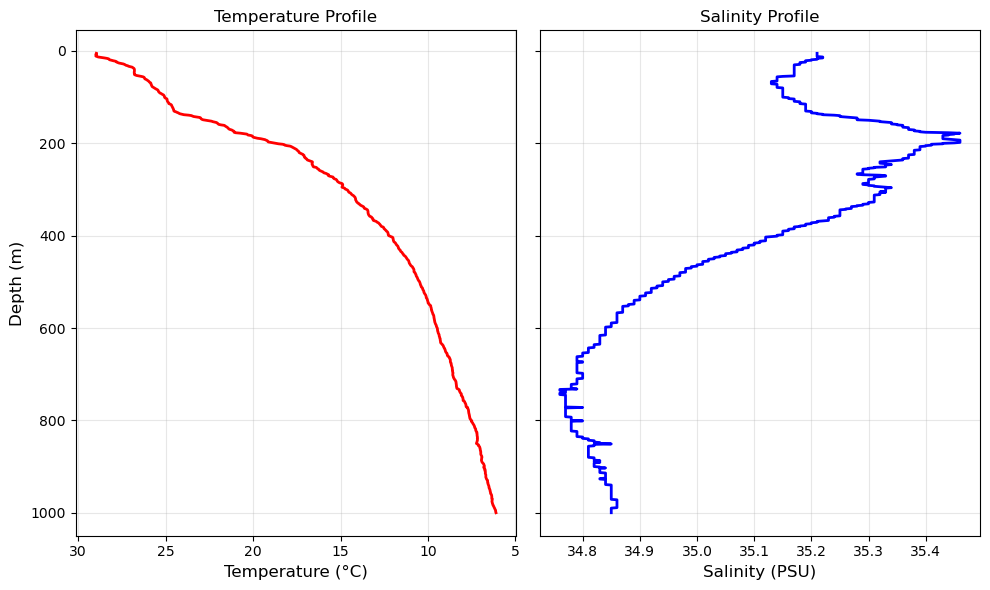

In [ ]:
# Load the CSV
df = pd.read_csv('CTD_11292008_0652')

# Create figure with two panels sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Temperature profile 
ax1.plot(df['Temperature_°C'], df['Depth_m'], color='red', linewidth=2, linestyle='-', marker='None')
ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_ylabel('Depth (m)', fontsize=12)
ax1.set_title('Temperature Profile', fontsize=12)
ax1.invert_xaxis()
ax1.grid(True, alpha=0.3)

# Salinity profile 
ax2.plot(df['Salinity_PSU'], df['Depth_m'], color='blue', linewidth=2, linestyle='-', marker='None')
ax2.set_xlabel('Salinity (PSU)', fontsize=12)
ax2.set_ylabel('')  # No y-label on right panel since shared
ax2.set_title('Salinity Profile', fontsize=12)
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3)

# Adjust spacing between subplots
plt.tight_layout()

# Show plot
plt.show()
plt.savefig('profiles.png', dpi=300, bbox_inches='tight')

* Part 3

In [20]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
# 1. Load the CSV file using the time column as the index

file_path = "SAA2_WC_2017_metocean_10min_avg.csv"

# Read the CSV file
# Missing values such as blank cells and NaN are automatically recognised
# by pandas.
df = pd.read_csv(
    file_path,
    parse_dates=['TIME_SERVER'],
    index_col='TIME_SERVER',
    na_values=['', 'NaN', 'nan']
)

# Display basic information
print("\nDataset information:")
print(df.info())

print("\nFirst five rows:")
print(df.head())

# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Dataset information:
<class 'pandas.DataFrame'>
DatetimeIndex: 2202 entries, 2017-06-28 17:10:00 to 2017-07-14 00:00:00
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               2202 non-null   int64  
 1   TIME_GPS         1977 non-null   str    
 2   LATITUDE         1977 non-null   float64
 3   N_S              1977 non-null   str    
 4   LONGITUDE        1977 non-null   float64
 5   E_W              1977 non-null   str    
 6   HUMIDITY         1977 non-null   float64
 7   BAROMETER        1977 non-null   float64
 8   AIR_TEMPERATURE  1977 non-null   float64
 9   WIND_SPEED_REL   1977 non-null   float64
 10  WIND_SPEED_TRUE  1974 non-null   float64
 11  WIND_DIR_REL     1977 non-null   float64
 12  WIND_DIR_TRUE    1974 non-null   float64
 13  PAR              1976 non-null   float64
 14  TSG_SALINITY     1863 non-null   float64
 15  TSG_TEMP         1863 non-null   float64
dtypes: float64(12

In [22]:
# ------------------------------------------------------------
# 2. Select data from departure date to a specified end date
# ------------------------------------------------------------

# Departure date = first timestamp in the dataset
start_date = df.index.min()

# Specify the end date here
# Example:
end_date = '2017-07-05'

# Select data from departure to the specified date (inclusive)
selected_data = df.loc[start_date:end_date]

print("\nSelected data range:")
print(selected_data.index.min(), "to", selected_data.index.max())


Selected data range:
2017-06-28 17:10:00 to 2017-07-05 23:50:00


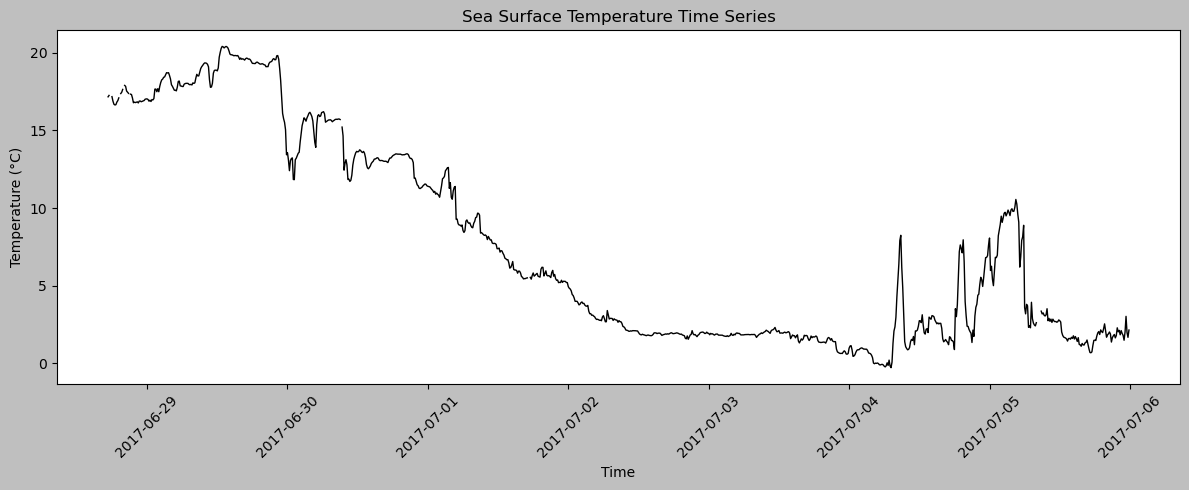

In [23]:
# ------------------------------------------------------------
# 3. Plot time series of temperature
# ------------------------------------------------------------

plt.style.use('grayscale')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(selected_data.index,
        selected_data['TSG_TEMP'],
        linewidth=1)

ax.set_title('Sea Surface Temperature Time Series')
ax.set_xlabel('Time')
ax.set_ylabel('Temperature (°C)')

plt.xticks(rotation=45)
plt.tight_layout()

# Save figure
plt.savefig('temperature_timeseries_grayscale.png', dpi=300)
plt.show()

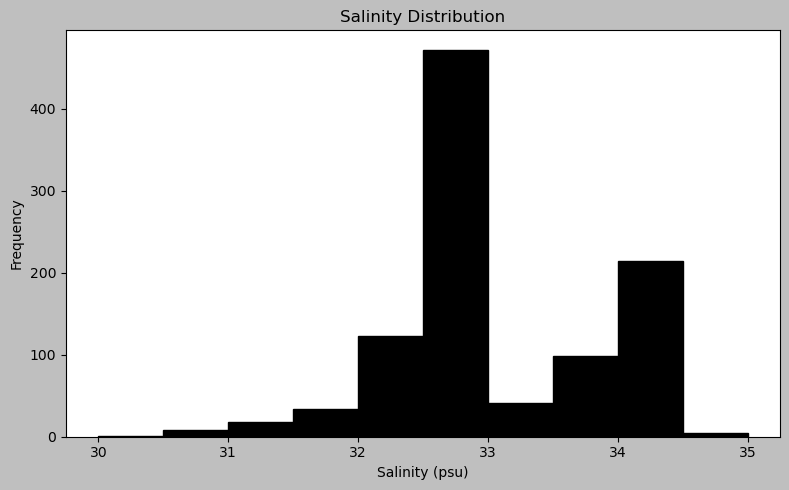

In [47]:
# ------------------------------------------------------------
# 4. Histogram of salinity distribution
# ------------------------------------------------------------

# Define histogram bins from 30 to 35 with interval 0.5
bins = np.arange(30, 35.5, 0.5)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(selected_data['TSG_SALINITY'].dropna(),
        bins=bins,
        edgecolor='black')

ax.set_title('Salinity Distribution')
ax.set_xlabel('Salinity (psu)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('salinity_histogram.png', dpi=300)
plt.show()

In [26]:
# ------------------------------------------------------------
# 5. Statistical summary table
# ------------------------------------------------------------

# Function to calculate IQR
# IQR = Q3 - Q1

def calculate_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return q3 - q1

# Create summary table
summary_table = pd.DataFrame({
    'Mean': [
        selected_data['TSG_TEMP'].mean(),
        selected_data['TSG_SALINITY'].mean()
    ],
    'Standard Deviation': [
        selected_data['TSG_TEMP'].std(),
        selected_data['TSG_SALINITY'].std()
    ],
    'Interquartile Range': [
        calculate_iqr(selected_data['TSG_TEMP'].dropna()),
        calculate_iqr(selected_data['TSG_SALINITY'].dropna())
    ]
}, index=['Temperature', 'Salinity'])

print("\nStatistical Summary:")
print(summary_table)

# Optional: Save table to CSV
summary_table.to_csv('summary_statistics.csv')


Statistical Summary:
                  Mean  Standard Deviation  Interquartile Range
Temperature   7.548058            6.547455            11.366525
Salinity     32.909449            1.460183             1.274600


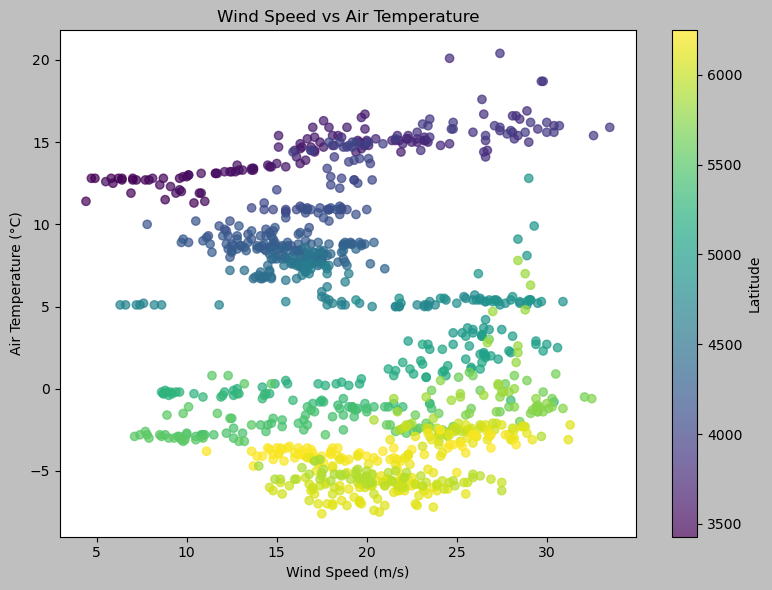


Analysis complete.


In [28]:
# ------------------------------------------------------------
# 6. Scatter plot: Wind speed vs air temperature
#    Latitude encoded as colour
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    selected_data['WIND_SPEED_TRUE'],
    selected_data['AIR_TEMPERATURE'],
    c=selected_data['LATITUDE'],
    cmap='viridis',
    alpha=0.7
)

# Add colour bar
cbar = plt.colorbar(scatter)
cbar.set_label('Latitude')

ax.set_title('Wind Speed vs Air Temperature')
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Air Temperature (°C)')

plt.tight_layout()

# Save figure as PNG with 300 DPI
plt.savefig('wind_vs_airtemperature.png', dpi=300)
plt.show()

print("\nAnalysis complete.")